## Datenbereinigung

In [1]:
#relevante Packages importieren
import pandas as pd 
import numpy as np
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
import itertools
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings('ignore')


In [2]:
# Datei einlesen
df_masterprojekt1 = pd.read_csv(
	'data/data_KIundDemokratie_2025-11-04_20-48.csv',
	sep='\t', encoding='utf-16', engine='python', on_bad_lines='warn', header=0
)

# Spaltennamen säubern (Null-Bytes, BOM, Anführungszeichen, Trim)
df_masterprojekt1.columns = (
	df_masterprojekt1.columns.astype(str)
	.str.replace(r'[\x00\ufeff"]', '', regex=True)
	.str.strip()
)

# String-Spalten (object) bereinigen: Null-Bytes entfernen + trim
obj = df_masterprojekt1.select_dtypes(include='object').columns
if len(obj):
	df_masterprojekt1[obj] = df_masterprojekt1[obj].apply(
		lambda s: s.astype(str).str.replace('\x00', '', regex=False).str.strip()
	)

In [3]:
# Datensatz einlesen

df_masterprojekt1 = pd.read_csv(
    'data/data_KIundDemokratie_2025-11-04_20-48.csv',
    sep='\t',          # Tabulator getrennt (Tab/Leerzeichen statt Komma oder Semikolon)
    encoding='utf-16', 
)

In [37]:
pd.set_option('display.max_columns', None)  # zeigt alle Spalten
# pd.set_option('display.expand_frame_repr', False)
df_masterprojekt1.head(5)


,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,CH01_01,IN02_CP,IN02,PA01_01,PA01_02,PA01_03,PA01_04,PA01_05,PA01_06,PA01_07,PA02_01,PA02_02,PA02_03,PA02_04,PA02_05,PA02_06,PA02_07,PA02_08,PA02_09,PA02_10,PA02_11,PA02_12,PA03_01,PA03_02,PA03_03,PA03_04,PA03_05,PA03_06,PA03_07,PA03_08,PA03_09,PA04,PA05_01,PA05_02,PA06_01,PA06_02,PA06_03,PA06_04,PA06_05,PA06_06,PA06_07,PA06_08,PA06_09,PA06_10,PA06_11,PA06_12,PA06_13,PA07_01,PA07_02,PA07_03,PA07_04,PA08_01,PA08_02,PA08_03,PA08_04,PA08_05,PA08_06,PA08_07,PA08_08,PA08_09,PA08_10,PA08_11,PA08_12,PA09_01,PA09_02,PA09_03,PA09_04,PA10_01,PA10_02,PA10_03,PA10_04,PA11_01,PA11_02,PA11_03,PA11_04,PA12_01,PA12_02,PA12_03,PA12_04,PA12_05,PA12_06,PA12_07,PA12_08,PC01,PC02,PC03_01,PC03_02,PC03_03,PC03_04,PC03_05,PC03_06,PC03_07,PC03_08,PC04,PT01_01,PT01_01a,PT02,PT03,PT04_01,PT04_02,PT05_01,PT05_02,PT05_03,PT05_04,PT05_05,PT05_06,PT05_07,PT05_08,PT06_01,PT06_02,PT06_03,PT06_04,PT06_05,PT06_06,PT06_07,PT06_08,PT07,PT08,PT09_01,PT09_02,QA01_01,QA01_02,QA01_03,TE02,TE03_01,TR02,TIME001,TIME003,TIME004,TIME005,TIME006,TIME007,TIME008,TIME009,TIME010,TIME011,TIME018,TIME019,TIME020,TIME021,TIME022,TIME023,TIME024,TIME025,TIME026,TIME027,TIME028,TIME029,TIME030,TIME032,TIME033,TIME034,TIME035,TIME036,TIME037,TIME038,TIME039,TIME040,TIME041,TIME042,TIME043,TIME044,TIME_SUM,MAILSENT,LASTDATA,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI,IN02_new,faktenbasiert_dich,empathisch_dich,gemischt_dich,PA03_01_inv,PA03_03_inv,PA03_07_inv,PA03_08_inv,PA03_09_inv,affektive_polarisierung,index_vertauth,index_freiheitseinschraenkung,index_affreaktanz,index_kogreaktanz,index_reaktanz,PT01_01_new
0,757,NaN,NaN,base,interview,2025-11-03 11:56:33,chatbot: Hallo! Wir wollen heute über eine Obe...,0,4,4,4,5,3,4,1,1,4,7,1,3,5,5,7,1,3,3,4,6,1,5,1,1,2,4,1,1,3,5,2,11,4,4,6,5,4,5,3,3,1,1,1,6,2,1,7,7,2,1,7,2,1,1,1,6,6,5,3,4,5,1,1,1,1,7,1,3,3,7,3,2,4,1,1,7,1,4,7,7,7,3,3,5,1,5,5,4,2,2,3,3,1993,1,2,6,7,3,5,7,7,6,2,2,1,1,5,5,4,4,4,4,5,7,6,5,4,11,2,6,3,1,NaN,1,9,11,59,28,41,12,8,18,10,8,NaN,NaN,NaN,NaN,NaN,481.0,NaN,NaN,26,65,39,19,23,52,27,64,24,24,34,42,7,12,65,16,2,6,1195,NaN,2025-11-03 12:17:05,NaN,1,0,44,44,1,0,"1,24",faktenbasiert,1,0,0,7,7,7,7,5,9,4.333333,4.00,4.000000,6.333333,4.777778,32
1,764,NaN,NaN,base,interview,2025-11-03 14:02:50,chatbot: Hallo! Wir wollen heute über eine Obe...,0,3,1,1,1,2,7,4,3,2,2,6,5,3,6,6,2,1,1,1,1,5,3,3,2,3,5,3,5,3,3,3,8,2,3,2,2,2,3,2,2,4,4,6,2,6,1,7,6,3,5,5,6,1,3,1,6,6,3,2,6,6,3,3,5,5,-1,2,4,5,7,-1,2,5,2,3,6,-1,6,6,4,6,4,5,3,1,5,4,4,2,4,1,-1,2004,1,2,5,6,4,5,6,4,5,6,4,6,6,5,4,6,5,4,6,6,3,4,3,2,9,2,6,3,1,NaN,2,5,16,15,24,43,19,6,27,7,6,NaN,NaN,NaN,NaN,257.0,NaN,NaN,NaN,20,35,38,19,76,73,31,47,31,26,65,31,6,10,44,21,5,2,948,NaN,2025-11-03 14:19:35,NaN,1,0,44,44,1,0,"1,38",empathisch,0,1,0,3,5,5,3,5,5,3.833333,1.00,2.666667,3.666667,2.444444,21
2,772,NaN,NaN,base,interview,2025-11-03 18:58:58,chatbot: Hallo! Wir wollen heute über eine Obe...,0,2,3,3,5,4,4,3,3,3,2,3,4,2,4,6,2,3,3,3,3,5,3,3,3,4,4,5,3,5,3,6,6,4,3,3,3,3,5,4,4,3,3,3,3,5,2,7,7,2,2,2,1,1,1,1,5,6,5,2,2,4,5,2,4,5,5,2,3,3,6,4,2,2,2,1,2,4,4,4,3,5,3,7,3,1,4,4,3,2,3,2,1,2004,1,2,5,6,4,6,5,5,7,5,5,4,2,6,2,3,3,2,3,5,4,4,3,6,6,2,6,3,1,NaN,1,22,23,21,42,57,29,10,28,9,9,NaN,NaN,NaN,447.0,NaN,NaN,NaN,NaN,21,37,43,13,12,35,27,52,21,29,28,51,8,14,52,16,18,4,1178,NaN,2025-11-03 19:18:36,NaN,1,0,44,44,1,0,"1,12",gemischt,0,0,1,3,5,3,5,3,0,3.666667,3.00,3.777778,3.666667,3.481481,21
3,773,NaN,NaN,base,pretest,2025-11-03 21:29:54,chatbot: Hallo! Wir wollen heute über eine Obe...,0,6,3,3,3,3,4,4,4,5,3,4,5,3,4,7,2,3,3,3,3,5,3,2,4,5,5,3,3,3,4,4,8,3,3,5,3,5,3,5,3,3,3,4,4,3,3,5,5,5,2,3,4,1,2,2,5,5,5,2,3,5,3,2,3,4,5,4,3,5,3,2,3,3,4,2,2,3,4,4,4,6,3,4,3,1,5,2,4,4,3,2,3,1999,1,2,4,6,4,6,5,6,4,5,5,5,5,3,5,6,3,3,4,4,4,4,4,5,8,2,6,2,1,NaN,1,7,18,9,19,41,8,6,15,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,483.0,22,44,37,17,11,42,21,48,16,21,38,30,7,18,112,10,2,4,1059,NaN,2025-11-03 21:48:28,NaN,1,0,44,44,1,0,"1,64",empathisch,0,1,0,3,6,5,5,5,4,4.833333,3.00,3.666667

In [40]:
#Missing Values, Exremwerte & Ausreißer überprüfen

In [5]:
# Test: Häufigkeiten der Werte ausgeben lassen (Check, ob wir NaNs oder ungültige Werte haben)

df_masterprojekt1['PA03_01'].value_counts(dropna=False)

PA03_01
5    4
1    3
2    3
4    2
3    2
Name: count, dtype: int64

In [6]:
df_masterprojekt1['IN02'].value_counts(dropna=False)

IN02
6    3
1    3
4    2
3    2
2    2
5    2
Name: count, dtype: int64

In [7]:
# Gruppen zusammenfassen (Kommunikationsstile)

# 1+4=faktenbasiert, 2+5=gemischt, 3+6=empathisch
in02_num = pd.to_numeric(df_masterprojekt1['IN02'], errors='coerce')
_map = {1: 'faktenbasiert', 4: 'faktenbasiert',
        2: 'gemischt',     5: 'gemischt',
        3: 'empathisch',   6: 'empathisch'}
df_masterprojekt1['IN02_new'] = in02_num.map(_map)

df_masterprojekt1['IN02_new'].value_counts(dropna=False)

IN02_new
faktenbasiert    5
empathisch       5
gemischt         4
Name: count, dtype: int64

In [8]:
# Dichotome Dummyvariablen für Kommunikationsstile erstellen
in02_num = pd.to_numeric(df_masterprojekt1['IN02'], errors='coerce')
map_dummyvariablen = {
    1: 'faktenbasiert',
    4: 'faktenbasiert',
    2: 'gemischt',
    5: 'gemischt',
    3: 'empathisch',
    6: 'empathisch'
}
df_masterprojekt1['IN02_new'] = in02_num.map(map_dummyvariablen)

df_masterprojekt1['faktenbasiert_dich'] = (df_masterprojekt1['IN02_new'] == 'faktenbasiert').astype(int)
df_masterprojekt1['empathisch_dich'] = (df_masterprojekt1['IN02_new'] == 'empathisch').astype(int)
df_masterprojekt1['gemischt_dich'] = (df_masterprojekt1['IN02_new'] == 'gemischt').astype(int)

#Kontrolle

df_masterprojekt1[['IN02', 'IN02_new', 'faktenbasiert_dich', 'gemischt_dich', 'empathisch_dich']].head()


,IN02,IN02_new,faktenbasiert_dich,gemischt_dich,empathisch_dich
0,4,faktenbasiert,1,0,0
1,3,empathisch,0,0,1
2,2,gemischt,0,1,0
3,6,empathisch,0,0,1
4,5,gemischt,0,1,0


#### Items umpolen (sodass höhere Werte "mehr" bedeuten)

In [9]:
# PA03_01 invertieren (7-stufig)
df_masterprojekt1['PA03_01_inv'] = 8 - df_masterprojekt1['PA03_01']

# Check
df_masterprojekt1[['PA03_01', 'PA03_01_inv']].head(10)

,PA03_01,PA03_01_inv
0,1,7
1,5,3
2,5,3
3,5,3
4,4,4
5,2,6
6,3,5
7,2,6
8,3,5
9,1,7


In [10]:
# PA03_03 invertieren (7-stufig)
df_masterprojekt1['PA03_03_inv'] = 8 - df_masterprojekt1['PA03_03']

# Check
df_masterprojekt1[['PA03_03', 'PA03_03_inv']].head(4)

,PA03_03,PA03_03_inv
0,1,7
1,3,5
2,3,5
3,2,6


In [11]:
# PA03_07 invertieren

df_masterprojekt1['PA03_07_inv'] = 8 - df_masterprojekt1['PA03_07']

# Check
df_masterprojekt1[['PA03_07', 'PA03_07_inv']].head(4)

,PA03_07,PA03_07_inv
0,1,7
1,3,5
2,5,3
3,3,5


In [12]:
# PA03_08 invertieren

df_masterprojekt1['PA03_08_inv'] = 8 - df_masterprojekt1['PA03_08']

# Check
df_masterprojekt1[['PA03_08', 'PA03_08_inv']].head(4)

,PA03_08,PA03_08_inv
0,1,7
1,5,3
2,3,5
3,3,5


In [13]:
# PA03_09 invertieren

df_masterprojekt1['PA03_09_inv'] = 8 - df_masterprojekt1['PA03_09']

# Check
df_masterprojekt1[['PA03_09', 'PA03_09_inv']].head(4)

,PA03_09,PA03_09_inv
0,3,5
1,3,5
2,5,3
3,3,5


In [14]:
# Affektive Polarisierung berechnen
# Differenz zwischen PA05_01 und PA05_02

df_masterprojekt1["affektive_polarisierung"] = (
    df_masterprojekt1["PA05_01"] - df_masterprojekt1["PA05_02"]
).abs() #abs steht für den absoluten Unterschied

# Kontrolltabelle mit den beiden Items und dem neuen Index
check_AP = df_masterprojekt1[["PA05_01", "PA05_02", "affektive_polarisierung"]]
print(check_AP.head(10))

   PA05_01  PA05_02  affektive_polarisierung
0        2       11                        9
1        3        8                        5
2        6        6                        0
3        4        8                        4
4        8        3                        5
5        4        8                        4
6        5        8                        3
7        3        9                        6
8        4       10                        6
9        3       10                        7


#### Mittelwertindizes bilden

In [15]:
# Vertrauen + wahrgenommene Authentizität
# Reliabilität checken (Cronachs Alpha)

# Auswahl der Variablen

items = ["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv"]
reliability_H2 = df_masterprojekt1[items].dropna()

def cronbach_alpha(reliability_H2):
    k = reliability_H2.shape[1]
    item_var = reliability_H2.var(axis=0, ddof=1)
    total_var = reliability_H2.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

alpha = cronbach_alpha(reliability_H2)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

for col in reliability_H2.columns:
    alpha_del = cronbach_alpha(reliability_H2.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.693
Alpha ohne PA03_04: 0.668
Alpha ohne PA03_05: 0.642
Alpha ohne PA03_06: 0.617
Alpha ohne PA03_07_inv: 0.673
Alpha ohne PA03_08_inv: 0.679
Alpha ohne PA03_09_inv: 0.637


In [16]:
# Mittelwertindex (Vertrauen + wahrgenommene Authentizität)

df_masterprojekt1["index_vertauth"] = df_masterprojekt1[["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_vertauth"].describe())
df_masterprojekt1[["PA03_04", "PA03_05", "PA03_06", "PA03_07_inv", "PA03_08_inv", "PA03_09_inv", "index_vertauth"]].head()

count    14.000000
mean      3.547619
std       0.996637
min       1.500000
25%       2.791667
50%       3.916667
75%       4.250000
max       4.833333
Name: index_vertauth, dtype: float64


,PA03_04,PA03_05,PA03_06,PA03_07_inv,PA03_08_inv,PA03_09_inv,index_vertauth
0,1,2,4,7,7,5,4.333333
1,2,3,5,5,3,5,3.833333
2,3,4,4,3,5,3,3.666667
3,4,5,5,5,5,5,4.833333
4,2,2,2,1,4,2,2.166667


In [17]:
# Reliabilität: wahrgenommene Freiheitseinschränkung

# Auswahl der Variablen
items = ["PA02_09", "PA02_10", "PA02_11", "PA02_12"]
reliability_einschraenkung = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_einschraenkung):
    k = reliability_einschraenkung.shape[1]
    item_var = reliability_einschraenkung.var(axis=0, ddof=1)
    total_var = reliability_einschraenkung.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_einschraenkung)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_einschraenkung.columns:
    alpha_del = cronbach_alpha(reliability_einschraenkung.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")


Cronbachs Alpha gesamt: 0.876
Alpha ohne PA02_09: 0.826
Alpha ohne PA02_10: 0.851
Alpha ohne PA02_11: 0.809
Alpha ohne PA02_12: 0.887


In [18]:
# Mittelwertindex: wahrgenommene Freiheitseinschränkung
df_masterprojekt1["index_freiheitseinschraenkung"] = df_masterprojekt1[["PA02_09", "PA02_10", "PA02_11", "PA02_12"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_freiheitseinschraenkung"].describe())
df_masterprojekt1[["PA02_09", "PA02_10", "PA02_11", "PA02_12", "index_freiheitseinschraenkung"]].head(5)


count    14.000000
mean      3.196429
std       1.461620
min       1.000000
25%       2.125000
50%       3.000000
75%       3.812500
max       6.500000
Name: index_freiheitseinschraenkung, dtype: float64


,PA02_09,PA02_10,PA02_11,PA02_12,index_freiheitseinschraenkung
0,3,3,4,6,4.00
1,1,1,1,1,1.00
2,3,3,3,3,3.00
3,3,3,3,3,3.00
4,1,3,2,1,1.75


In [19]:
# affektive Reaktanz-Dimension

# Auswahl der Variablen
items = ["PA06_01", "PA06_02", "PA06_03", "PA06_04", "PA06_05", "PA06_06", "PA06_07", "PA06_08", "PA06_13"]
reliability_affreaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_affreaktanz):
    k = reliability_affreaktanz.shape[1]
    item_var = reliability_affreaktanz.var(axis=0, ddof=1)
    total_var = reliability_affreaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_affreaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_affreaktanz.columns:
    alpha_del = cronbach_alpha(reliability_affreaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.853
Alpha ohne PA06_01: 0.808
Alpha ohne PA06_02: 0.807
Alpha ohne PA06_03: 0.832
Alpha ohne PA06_04: 0.826
Alpha ohne PA06_05: 0.816
Alpha ohne PA06_06: 0.826
Alpha ohne PA06_07: 0.819
Alpha ohne PA06_08: 0.823
Alpha ohne PA06_13: 0.932


In [20]:
# Mittelwertindex: affektive Reaktanz-Dimension

df_masterprojekt1["index_affreaktanz"] = df_masterprojekt1[["PA06_01", "PA06_02", "PA06_03", "PA06_04", "PA06_05", "PA06_06", "PA06_07", "PA06_08", "PA06_13"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_affreaktanz"].describe())
df_masterprojekt1[["PA06_01", "PA06_02", "PA06_03", "PA06_04", "PA06_05", "PA06_06", "PA06_07", "PA06_08", "PA06_13", "index_affreaktanz"]].head()

count    14.000000
mean      3.706349
std       1.045596
min       1.333333
25%       3.333333
50%       3.722222
75%       4.361111
max       5.777778
Name: index_affreaktanz, dtype: float64


,PA06_01,PA06_02,PA06_03,PA06_04,PA06_05,PA06_06,PA06_07,PA06_08,PA06_13,index_affreaktanz
0,4,4,6,5,4,5,3,3,2,4.000000
1,2,3,2,2,2,3,2,2,6,2.666667
2,4,3,3,3,3,5,4,4,5,3.777778
3,3,3,5,3,5,3,5,3,3,3.666667
4,1,1,2,1,1,3,1,1,1,1.333333


In [21]:
# kognitive Reaktanz-Dimension

# Auswahl der Variablen
items = ["PA03_01_inv", "PA03_02", "PA03_03_inv"]
reliability_kogreaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_kogreaktanz):
    k = reliability_kogreaktanz.shape[1]
    item_var = reliability_kogreaktanz.var(axis=0, ddof=1)
    total_var = reliability_kogreaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_kogreaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_kogreaktanz.columns:
    alpha_del = cronbach_alpha(reliability_kogreaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")

Cronbachs Alpha gesamt: 0.819
Alpha ohne PA03_01_inv: 0.605
Alpha ohne PA03_02: 0.809
Alpha ohne PA03_03_inv: 0.806


In [22]:
# Mittelwertindex: kognitive Reaktanz-Dimension

df_masterprojekt1["index_kogreaktanz"] = df_masterprojekt1[["PA03_01_inv", "PA03_02", "PA03_03_inv"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_kogreaktanz"].describe())
df_masterprojekt1[["PA03_01_inv", "PA03_02", "PA03_03_inv", "index_kogreaktanz"]].head()

count    14.000000
mean      4.904762
std       1.283881
min       3.000000
25%       3.750000
50%       4.666667
75%       6.000000
max       6.666667
Name: index_kogreaktanz, dtype: float64


,PA03_01_inv,PA03_02,PA03_03_inv,index_kogreaktanz
0,7,5,7,6.333333
1,3,3,5,3.666667
2,3,3,5,3.666667
3,3,3,6,4.000000
4,4,2,7,4.333333


In [23]:
# Reaktanz

# Auswahl der Variablen
items = ["PA03_01_inv", "PA03_02", "PA03_03_inv", 
         "PA06_01", "PA06_02", "PA06_03", "PA06_04", "PA06_05", "PA06_06", "PA06_07", "PA06_08", "PA06_13", 
         "PA02_09", "PA02_10", "PA02_11", "PA02_12"]
reliability_reaktanz = df_masterprojekt1[items].dropna()

# Funktion zur Berechnung von Cronbachs Alpha
def cronbach_alpha(reliability_reaktanz):
    k = reliability_reaktanz.shape[1]
    item_var = reliability_reaktanz.var(axis=0, ddof=1)
    total_var = reliability_reaktanz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var.sum() / total_var)

# Berechnung von Cronbachs Alpha gesamt
alpha = cronbach_alpha(reliability_reaktanz)
print(f"Cronbachs Alpha gesamt: {alpha:.3f}")

# Berechnung von Cronbachs Alpha, wenn jeweils ein Item entfernt wird
for col in reliability_reaktanz.columns:
    alpha_del = cronbach_alpha(reliability_reaktanz.drop(columns=[col]))
    print(f"Alpha ohne {col}: {alpha_del:.3f}")


Cronbachs Alpha gesamt: 0.912
Alpha ohne PA03_01_inv: 0.902
Alpha ohne PA03_02: 0.899
Alpha ohne PA03_03_inv: 0.911
Alpha ohne PA06_01: 0.901
Alpha ohne PA06_02: 0.901
Alpha ohne PA06_03: 0.908
Alpha ohne PA06_04: 0.906
Alpha ohne PA06_05: 0.902
Alpha ohne PA06_06: 0.898
Alpha ohne PA06_07: 0.900
Alpha ohne PA06_08: 0.906
Alpha ohne PA06_13: 0.941
Alpha ohne PA02_09: 0.903
Alpha ohne PA02_10: 0.910
Alpha ohne PA02_11: 0.904
Alpha ohne PA02_12: 0.901


In [24]:
# Mittelwertindex: Reaktanz

df_masterprojekt1["index_reaktanz"] = df_masterprojekt1[["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"]].mean(axis=1, skipna=True)

# Kontrolle: Verteilung und erste Werte
print(df_masterprojekt1["index_reaktanz"].describe())
df_masterprojekt1[["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung", "index_reaktanz"]].head()

count    14.000000
mean      3.935847
std       1.103072
min       2.444444
25%       3.048611
50%       3.680556
75%       4.773148
max       5.870370
Name: index_reaktanz, dtype: float64


,index_affreaktanz,index_kogreaktanz,index_freiheitseinschraenkung,index_reaktanz
0,4.000000,6.333333,4.00,4.777778
1,2.666667,3.666667,1.00,2.444444
2,3.777778,3.666667,3.00,3.481481
3,3.666667,4.000000,3.00,3.555556
4,1.333333,4.333333,1.75,2.472222


## Deskriptive Statistiken

### Geschlecht

          Absolute Häufigkeit  Relative Häufigkeit (%)
PT02                                                  
Männlich                    1                     7.14
Weiblich                   13                    92.86


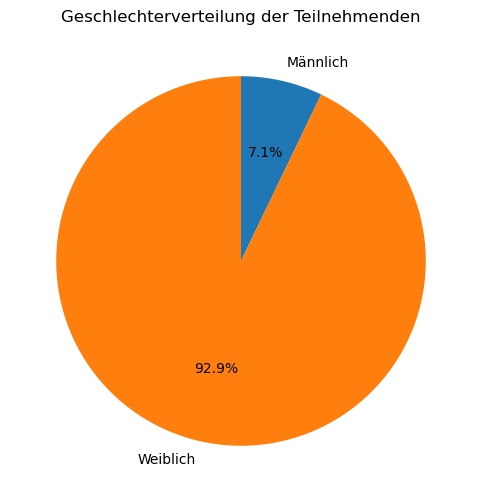

In [62]:
# Deskriptive Statistiken (Häufigkeiten prozentual und absolut) für PT02

absolute = df_masterprojekt1['PT02'].value_counts().sort_index()
relative = df_masterprojekt1['PT02'].value_counts(normalize=True).sort_index()

haeufigkeitstabelle = pd.DataFrame({
    'Absolute Häufigkeit': absolute,
    'Relative Häufigkeit (%)': (relative * 100).round(2)
})

haeufigkeitstabelle.index = haeufigkeitstabelle.index.map({1: 'Männlich', 2: 'Weiblich'})
print(haeufigkeitstabelle)

# Kreisdiagramm

labels = ['Männlich', 'Weiblich']

plt.figure(figsize=(6, 6))
plt.pie(
    relative, 
    labels=labels, 
    autopct='%1.1f%%',   # Eine Nachkommastelle
    startangle=90,       # Startwinkel für schönere Ausrichtung
    counterclock=False   # damit das Diagramm im Uhrzeigersinn läuft
)

plt.title('Geschlechterverteilung der Teilnehmenden')
plt.show()


### Alter

In [39]:
# Zur Errechnung des Alters in Jahren: 2025 - Geburtstjahr PT01_01
df_masterprojekt1['PT01_01_new'] = 2025 - df_masterprojekt1['PT01_01']

# Kontrolle: erste Werte
df_masterprojekt1['PT01_01_new'].head()

0    32
1    21
2    21
3    26
4    66
Name: PT01_01_new, dtype: int64

In [41]:
# Deskriptive Statistiken (Mittelwert, Median, SD, Min, Max)

df_masterprojekt1['PT01_01_new'].describe()

count    14.000000
mean     29.428571
std      16.416288
min      20.000000
25%      21.250000
50%      22.000000
75%      25.500000
max      69.000000
Name: PT01_01_new, dtype: float64

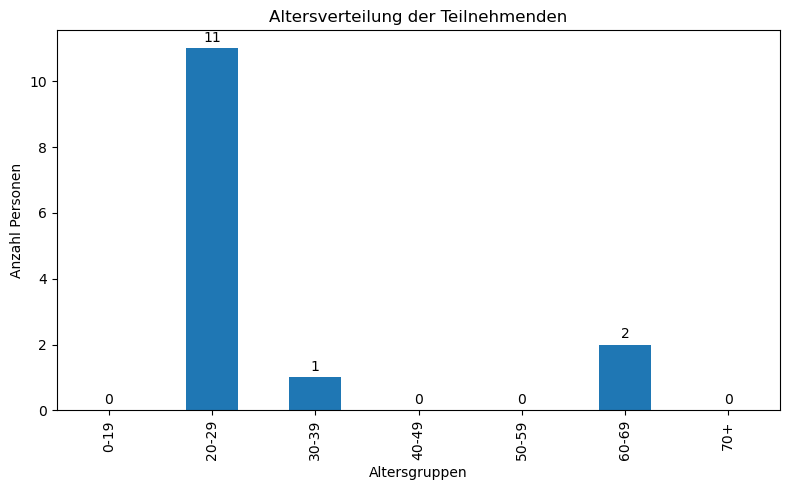

In [61]:
# Balkendiagramm Alterverteilung in Altersgruppen (0-19, 20-29, 30-39, 40-49, 50-59, 60-69, 70+)

# Altersgruppen definieren
bins = [0, 19, 29, 39, 49, 59, 69, 120]
labels = ['0-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

# Alterswerte in Gruppen einteilen
df_masterprojekt1['Altersgruppe'] = pd.cut(df_masterprojekt1['PT01_01_new'], bins=bins, labels=labels, right=True)

# Anzahl pro Gruppe zählen
altersverteilung = df_masterprojekt1['Altersgruppe'].value_counts().sort_index()

# Balkendiagramm erstellen
plt.figure(figsize=(8, 5))
altersverteilung.plot(kind='bar')

# Titel und Achsenbeschriftungen
plt.title('Altersverteilung der Teilnehmenden')
plt.xlabel('Altersgruppen')
plt.ylabel('Anzahl Personen')

# Werte auf den Balken anzeigen
for i, v in enumerate(altersverteilung):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()


### Höchster Bildungsabschluss

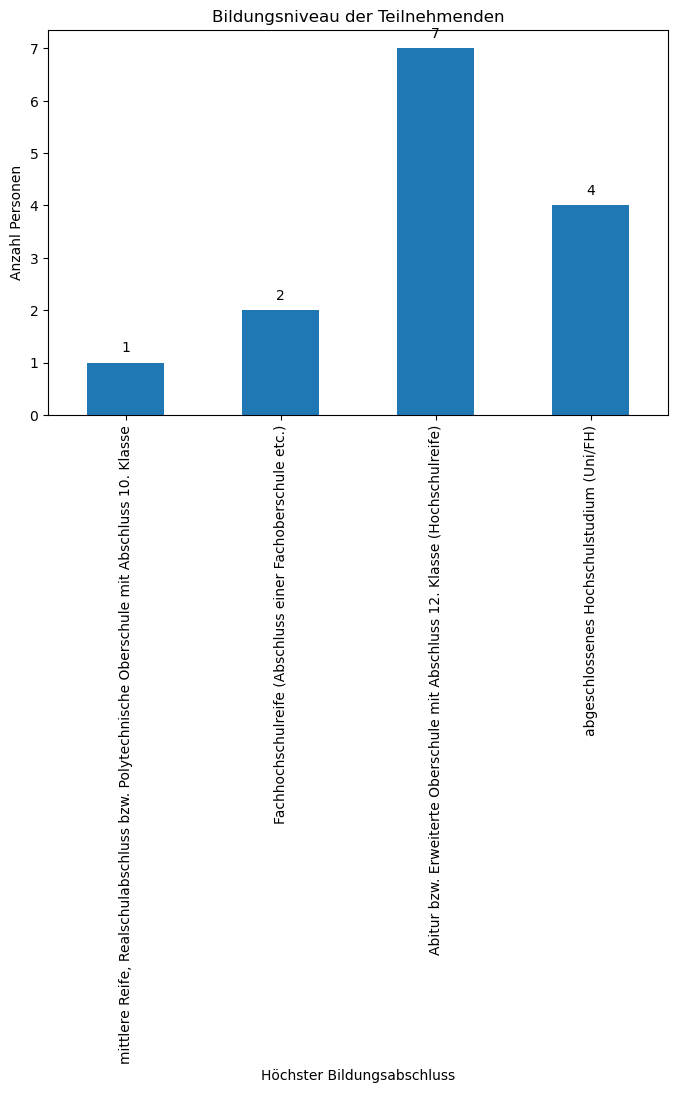

In [60]:
# Deskriptive Statistiken
df_masterprojekt1['PT03'].describe()

# Balkendiagramm erstellen
bildungsniveau = df_masterprojekt1['PT03'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
bildungsniveau.plot(kind='bar')

# Labels für Bildungsniveau – die Beschriftung könnte man evtl. nur kürzer formulieren
labels_bildung = {
    1: 'Schüler/-in, besuche eine allgemeinbildende Vollzeitschule',
    2: 'Volks- / Hauptschulabschluss bzw. Polytechnische Oberschule mit Abschluss 8. oder 9. Klasse',
    3: 'mittlere Reife, Realschulabschluss bzw. Polytechnische Oberschule mit Abschluss 10. Klasse',
    4: 'Fachhochschulreife (Abschluss einer Fachoberschule etc.)',
    5: 'Abitur bzw. Erweiterte Oberschule mit Abschluss 12. Klasse (Hochschulreife)',
    6: 'abgeschlossenes Hochschulstudium (Uni/FH)',
}

# Achsenbeschriftung mit Textlabels ersetzen
plt.xticks(ticks=range(len(bildungsniveau)),
           labels=[labels_bildung[i] for i in bildungsniveau.index],
           rotation=90)

# Titel und Achsenbeschriftungen
plt.title('Bildungsniveau der Teilnehmenden')
plt.xlabel('Höchster Bildungsabschluss')
plt.ylabel('Anzahl Personen')

# Werte auf den Balken anzeigen
for i, v in enumerate(bildungsniveau):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.show()


### Einstellung zur Obergenze

In [59]:
# Deskriptive Statistiken
df_masterprojekt1['PT07'].describe()

count    14.000000
mean      4.642857
std       1.336306
min       2.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       6.000000
Name: PT07, dtype: float64

In [64]:
# Einteilung in pro Obergrenze und contra Obergrenze – Werte von 01 bis 03 sind pro Obergrenze, 04 bis 06 contra Obergrenze

map_obergrenze = {
    1: 'pro Obergrenze',
    2: 'pro Obergrenze',
    3: 'pro Obergrenze',
    4: 'contra Obergrenze',
    5: 'contra Obergrenze',
    6: 'contra Obergrenze'
}
df_masterprojekt1['PT07_new'] = df_masterprojekt1['PT07'].map(map_obergrenze)

# Deskriptive Statistiken
df_masterprojekt1['PT07_new'].value_counts()

PT07_new
contra Obergrenze    11
pro Obergrenze        3
Name: count, dtype: int64

## Tests rechnen

### Hypothese 1

In [26]:
# Hypothese 1a: Ein Gespräch mit einem LLM, das einen faktenbasierten KS verwendet, führt bei Befragten zu einer stärkeren affektiven Polarisierung als ein empathischer sowie ein gemischter KS.

# Hypothese 1b:Ein gemischter KS führt zu einer geringeren affektiven Polarisierung als ein empathischer sowie faktenbasierter KS.


import itertools as it # brauchen wir, um später Kombinationen von Gruppen zu erzeugen (Paarvergleiche)

# Daten 
df_anovaH1 = df_masterprojekt1[['affektive_polarisierung', 'IN02_new']].dropna() # Dataframe erstellen mit den beiden Variablen (AP & KS)
df_anovaH1['IN02_new'] = df_anovaH1['IN02_new'].astype('category') #Umwandlung der Variable IN02_new in einen kategorialen Datentyp

# Gruppenübersicht - zeigt die AP deskriptiv für jeden Kommunikationsstil
print(df_anovaH1.groupby('IN02_new')['affektive_polarisierung'].agg(['count','mean','std']))

# ANOVA (Haupteffekt)
modelH1 = ols('affektive_polarisierung ~ C(IN02_new)', data=df_anovaH1).fit() # erstellt ein lineares Modell (ols) mit der Av affektive_polarisierung und der UV IN02_new
print(anova_lm(modelH1, typ=2)) # Durchführen einer Varianzanalyse 

# Post-hoc (Welch) + Bonferroni
groupsH1 = df_anovaH1['IN02_new'].cat.categories.tolist() # holt alle Kategorien (empathisch, faktenbasiert, gemischt) als Liste
pairs = list(it.combinations(groupsH1, 2)) # Erstellen aller möglichen 2er-Kombinationen dieser Gruppen (paarweiser Vergleich)

results = []
for g1, g2 in pairs:
    x = df_anovaH1.loc[df_anovaH1['IN02_new'] == g1, 'affektive_polarisierung']
    y = df_anovaH1.loc[df_anovaH1['IN02_new'] == g2, 'affektive_polarisierung']
    t, p = ttest_ind(x, y, equal_var=False, nan_policy='omit')
    results.append({'g1': g1, 'g2': g2, 'n1': x.size, 'n2': y.size, # Gruppennamen g1, g2; Stichprobengröße n1, n2
                    'm1': x.mean(), 'm2': y.mean(), 't': t, 'p_unc': p}) # Mittelwerte m1, m2; t-Wert: t; unkorrekten p-Wert: p_unc

p_adj = multipletests([r['p_unc'] for r in results], method='bonferroni') # holt alle unkorrekten p-Werte und korrigiert sie nac Bonferroni
for r, p_b, sig in zip(results, p_adj[1], p_adj[0]):# Hinzufügen des korrigierten Ergebnisses
    r['p_bonf'] = p_b # Bonferroni-korrigierten p-Wert
    r['sig_bonf'] = sig #True/False, ob signifikant nach Bonferroni 


posthoc_df = pd.DataFrame(results).sort_values('p_bonf') # Ergebnistabelle 
print(posthoc_df[['g1','g2','n1','n2','m1','m2','t','p_unc','p_bonf','sig_bonf']].round(4)) 

               count  mean       std
IN02_new                            
empathisch         5  3.80  2.280351
faktenbasiert      5  6.60  2.302173
gemischt           4  6.25  4.787136
             sum_sq    df         F    PR(>F)
C(IN02_new)   22.75   2.0  1.129797  0.357885
Residual     110.75  11.0       NaN       NaN
              g1             g2  n1  n2   m1    m2       t   p_unc  p_bonf  \
0     empathisch  faktenbasiert   5   5  3.8  6.60 -1.9322  0.0894  0.2683   
1     empathisch       gemischt   5   4  3.8  6.25 -0.9417  0.3986  1.0000   
2  faktenbasiert       gemischt   5   4  6.6  6.25  0.1343  0.8995  1.0000   

   sig_bonf  
0     False  
1     False  
2     False  


 Tendenziell höhere affektive Polarisierung bei faktenbasiert und gemischt als bei empathisch, aber Streuung sehr hoch, besonders bei gemischt. (siehe mean & std)
 
 F(2,11) = 1.13, p = 0.36 -> kein signifikanter Unterschied zwischen den drei Kommunikationsstilen hinsichtl. der AP
 
 Bonferroni Post-hoc-Vergleiche: kein Paarvergleich bleibt nach Bonferroni-Korrektur signifikant (siehe p-Wert nach Bonferroni-Korrektur: p_bonf & 3mal False)

### Hypothese 2

In [27]:
# Hypothese H2:Je höher das Vertrauen in den Chatbot ausfällt, desto geringer ist die Reaktanz gegenüber dem Chatbot.
# Bivariate Korrelation - UV: Mittelwertindex Vertrauen + wahrgenommene Authentizität, AV: Mittelwertindex Reaktanz

colsH2 = ['index_vertauth', 'index_reaktanz'] # definiert die zwei Spaltennamen, die für die Korrelation verwendet werden
df_corr = df_masterprojekt1[colsH2].apply(pd.to_numeric, errors='coerce').dropna() # Zeilen mit fehlende Werten entfernen

x, y = df_corr['index_vertauth'], df_corr['index_reaktanz'] # Kurzvariablen anlegen für Vertrauen (x) und Reaktanz (y)

print(f"n = {len(df_corr)}") # Stichprobengröße
print(df_corr.describe().loc[['mean','std']].round(3)) # Deskriptive Statistik ausgeben (Mittelwert, Standardabweichung)

# Korrelationen
r_p, p_p = pearsonr(x, y) # Pearson-Korrelation, inkl. p-Wert
r_s, p_s = spearmanr(x, y) # Spearman-Korrelation, inkl.p-Wert

# kompakte Tabelle ausgeben
out = pd.DataFrame({
    'Test': ['Pearson (r)', 'Spearman (ρ)'],
    'Koeffizient': [r_p, r_s],
    'p-Wert': [p_p, p_s],
    'Richtung (H2 erwartet negativ)': ['negativ' if r_p < 0 else 'positiv',
                                       'negativ' if r_s < 0 else 'positiv']
}).round(4)
print("\nErgebnisse:\n", out.to_string(index=False))


n = 14
      index_vertauth  index_reaktanz
mean           3.548           3.936
std            0.997           1.103

Ergebnisse:
         Test  Koeffizient  p-Wert Richtung (H2 erwartet negativ)
 Pearson (r)      -0.1959  0.5021                        negativ
Spearman (ρ)      -0.0354  0.9045                        negativ


In [28]:
# bei Bedarf: detailliertere Analyse (multivariate Regression)
# AV 1: wahrgenommene Freiheitseinschränkung; AV 2: affektive Reaktanz-Dimension; AV 3: kognitive Reaktanz-Dimension

# Daten vorbereiten
cols_regression = ['index_vertauth', 'index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung'] # Liste definieren mit unserer UV und den drei AVs
df_regressionH2 = df_masterprojekt1[cols_regression].apply(pd.to_numeric, errors='coerce').dropna() # relevanten Spalten auswählen & alle Werte in Zahlen umwandeln

X = df_regressionH2['index_vertauth'] # unabhängige Variable - unseren Prädiktor Vertrauen+ wahrgenommene Authentizität erstellen
X = sm.add_constant(X)  # Konstante hinzufügen (Achsenabschnitt für die Regressionsgerade)

# Liste der AVs
avs = ['index_affreaktanz', 'index_kogreaktanz', 'index_freiheitseinschraenkung']
av_namen = ['Affektive Reaktanz', 'Kognitive Reaktanz', 'Wahrgenommene Freiheitseinschränkung'] # lesbar für die ausgabe

print(f"Stichprobengröße: n = {len(df_regressionH2)}\n")
print("="*80) # Trennlinie (bessere Lesbarkeit)

# Schleife über alle drei Reaktanz-Dimensionen
for av, name in zip(avs, av_namen): # paralleles Durchlaufen der drei AVs
    print(f"\n### REGRESSION: {name} ###\n") # Überschrift für jede Regression
    
    y = df_regressionH2[av] # holt die aktuelle abhängige Variable aus dem DataFrame
    
    # Regression rechnen
    model = sm.OLS(y, X).fit() # OLS = Ordinary Least Squares (klassische lineare Regression)
    
    # Kompakte Ergebnistabelle
    resultsH2 = pd.DataFrame({
        'Koeffizient': model.params, # Regressionskoeffizienten (b1 = Steigung für Vertrauen)
        'SE': model.bse, # Standardfehler der Koeffizienten
        'β (standardisiert)': [0, stats.pearsonr(df_regressionH2['index_vertauth'], y)[0]],
        't-Wert': model.tvalues,
        'p-Wert': model.pvalues
    }).round(4)
    
    print(resultsH2)
    print(f"\nR² = {model.rsquared:.4f}") # Anteil der erklärten Variant
    print(f"Adj. R² = {model.rsquared_adj:.4f}") # korrigiertes R-Quadrat
    print(f"F-Statistik = {model.fvalue:.4f}, p = {model.f_pvalue:.4f}") # testen, ob das Gesamtmodell signifikant ist
    print(f"\nInterpretation: Pro Einheit mehr Vertrauen sinkt/steigt {name} um {model.params['index_vertauth']:.4f} Einheiten.")
    print("="*80)


Stichprobengröße: n = 14


### REGRESSION: Affektive Reaktanz ###

                Koeffizient      SE  β (standardisiert)  t-Wert  p-Wert
const                3.0878  1.0976              0.0000  2.8132  0.0157
index_vertauth       0.1743  0.2986              0.1662  0.5838  0.5702

R² = 0.0276
Adj. R² = -0.0534
F-Statistik = 0.3408, p = 0.5702

Interpretation: Pro Einheit mehr Vertrauen sinkt/steigt Affektive Reaktanz um 0.1743 Einheiten.

### REGRESSION: Kognitive Reaktanz ###

                Koeffizient      SE  β (standardisiert)  t-Wert  p-Wert
const                6.0321  1.3245              0.0000  4.5541  0.0007
index_vertauth      -0.3178  0.3604             -0.2467 -0.8817  0.3952

R² = 0.0608
Adj. R² = -0.0174
F-Statistik = 0.7775, p = 0.3952

Interpretation: Pro Einheit mehr Vertrauen sinkt/steigt Kognitive Reaktanz um -0.3178 Einheiten.

### REGRESSION: Wahrgenommene Freiheitseinschränkung ###

                Koeffizient      SE  β (standardisiert)  t-Wert  p-Wert
const 

### Hypothese 3

In [29]:
# Die Beziehung zwischen dem KS eines Chatbots und der affektiven Polarisierung wird durch die Reaktanz mediierend beeinflusst, wenn das Vertrauen in den Chatbot kontrolliert wird.


In [30]:
# Hypothese H3a:Ein faktenbasierter KS eines Chatbots führt zu einer stärkeren Reaktanz als ein empathischer sowie ein gemischter KS.

In [31]:
# Hypothese H3b:Ein gemischter KS eines Chatbots führt zu einer geringeren Reaktanz als ein empathischer sowie faktenbasierter KS. 

### Forschungsfrage 1

In [32]:
# Forschungsfrage 1: Inwiefern beeinflussen die drei KS eines Chatbots (empathisch, faktenbasiert, gemischt) die drei Reaktanz-Dimensionen(wahrgenommene Freiheitseinschränkung, Emotion, Kognition)?

# MANOVA - UV: Kommunikationsstile (faktenbasiert, empathisch, gemischt) & AV: drei Reaktanz-Dimensionen
# Listen erstellen
avs_manova = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"] # Liste der AVs
cols_manova = ["IN02_new", *avs_manova] # kombinierte Liste mit UV und AVs (fyi das * entpackt die Liste)

# Vrbereitung der Datem für den Test
df_manova = df_masterprojekt1[cols_manova].copy() # Unterdatensatz mit genau den Spalten, die wir für die Analyse brauchen
df_manova[avs_manova] = df_manova[avs_manova].apply(pd.to_numeric, errors="coerce") # AVs in numerische Typen umwandeln
df_manova = df_manova.dropna(subset=["IN02_new", *avs_manova]) # Zeilen mit fehlenden AVs entfernen
df_manova["IN02_new"] = df_manova["IN02_new"].astype("category") # Gruppierungsvariable als kategorial setzen

# Überblick
print(f"n = {len(df_manova)}") # Stichprobengröße
print(df_manova["IN02_new"].value_counts().sort_index()) # Gruppengrößen je Kommunikationsstil  
print(df_manova.groupby("IN02_new")[avs_manova].agg(["mean", "std", "count"]).round(3)) # Deskriptive Statistiken (M, SD, n) je KS und AV

# MANOVA
from statsmodels.multivariate.manova import MANOVA # MANOVA-Funktion importieren
results_manova = MANOVA.from_formula( # Formel 
    "index_affreaktanz + index_kogreaktanz + index_freiheitseinschraenkung ~ C(IN02_new)", # fyi das C erzwingt kategorial; mv_test berechnet die multivariaten Tests (Pillai, Wilks, Hotelling, Roy)
    data=df_manova
).mv_test()
print(results_manova) # liefert F-Werte, df und p-Wert für den Haupteffekt der KS auf die drei AVs


n = 14
IN02_new
empathisch       5
faktenbasiert    5
gemischt         4
Name: count, dtype: int64
              index_affreaktanz              index_kogreaktanz               \
                           mean    std count              mean    std count   
IN02_new                                                                      
empathisch                3.644  0.691     5             4.733  1.362     5   
faktenbasiert             3.889  0.716     5             5.600  1.090     5   
gemischt                  3.556  1.823     4             4.250  1.287     4   

              index_freiheitseinschraenkung               
                                       mean    std count  
IN02_new                                                  
empathisch                            3.700  2.057     5  
faktenbasiert                         3.400  1.154     5  
gemischt                              2.312  0.554     4  
                 Multivariate linear model
                             

In [33]:
# nächster Schritt bei Signifikanz: Univariate ANOVA & Post-hoc Tests rechnen

from statsmodels.stats.multicomp import pairwise_tukeyhsd # Tukey HSD für paarweise Gruppenvergleiche

avs_anovaF1 = ["index_affreaktanz", "index_kogreaktanz", "index_freiheitseinschraenkung"] # Liste der AVs für univariate ANOVA
anova_rows_f1, tukey_results_f1 = [], {} # Container für kompakte ANOVA-Übersicht

for av in avs_anovaF1: # Schleife: gleiches Vorgehen je AV
    model_f1 = ols(f"{av} ~ C(IN02_new)", data=df_manova).fit() # OLS-Modell pro AV mit kategorialer UV (siehe C)
    anova_f1 = anova_lm(model_f1, typ=2)
    p_val = anova_f1.loc["C(IN02_new)", "PR(>F)"]
    eta2 = anova_f1.loc["C(IN02_new)", "sum_sq"] / anova_f1["sum_sq"].sum()
    
    anova_rows_f1.append({
        "AV": av,
        "F": anova_f1.loc["C(IN02_new)", "F"],
        "p": p_val,
        "eta²": eta2
    }) 
 
anova_table_f1 = pd.DataFrame(anova_rows_f1) # Ergebnistabelle 
print("\nANOVA-Übersicht (F1):")
print(anova_table_f1.round(3))

# Post-hoc Tests ergänzen (vorab: Levene-Test auf Varianzhomogenität) -> Welch-Test, Games Howell


ANOVA-Übersicht (F1):
                              AV      F      p   eta²
0              index_affreaktanz  0.109  0.898  0.019
1              index_kogreaktanz  1.372  0.294  0.200
2  index_freiheitseinschraenkung  1.092  0.369  0.166
